In [ ]:
# Core
import pandas as pd
import numpy as np

# Graficas
import matplotlib.pyplot as plt
import seaborn as sns

#Modelo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_disease_uci.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


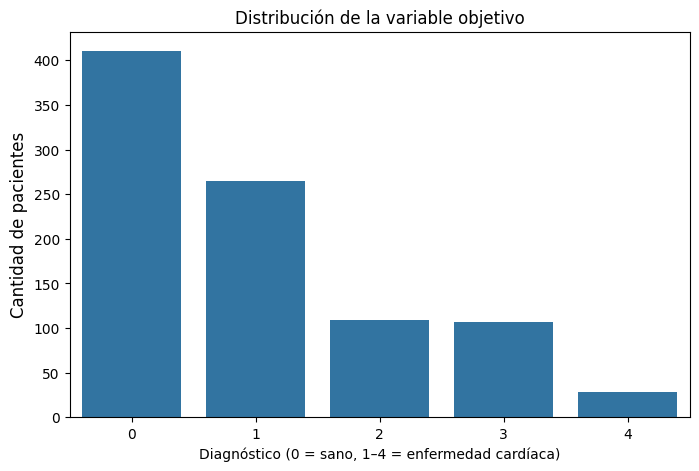

In [ ]:
# Crear gráfico de conteo
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="num")

plt.title("Distribución de la variable objetivo",)
plt.xlabel("Diagnóstico (0 = sano, 1–4 = enfermedad cardíaca)")
plt.ylabel("Cantidad de pacientes", fontsize=12)

plt.show()

Se podrian decir que el dataframe esta ligeramente equilibrado ya que aproximadamente 500 casos son positivos y aproximadamente 400 no lo son

In [ ]:
# Eliminar columnas
df = df.drop('ca', axis=1)
df = df.drop('thal', axis=1)

# Dejar solo columnas numericas
df = df.select_dtypes(include=[np.number])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   trestbps  861 non-null    float64
 3   chol      890 non-null    float64
 4   thalch    865 non-null    float64
 5   oldpeak   858 non-null    float64
 6   num       920 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 50.4 KB


Las columnas 'ca' y 'thal' se eliminan debido a que tienen mas de la mitad de los valores nulos, y se dejan solo las columnas numericas para que el modelo funcione correctamente

In [ ]:
# Imputar columna trestbps con la media
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].mean())
df['trestbps'].isnull().sum()

np.int64(0)

La columna se imputa con la media debido a que no posee muchos valores atipicos

In [ ]:
# Imputar columna chol mediana
df['chol'] = df['chol'].fillna(df['chol'].median())
df['chol'].isnull().sum()

np.int64(0)

La columna se imputa con la mediana debido a que posee valores atipicos y no tiene una moda tan frecuente

In [ ]:
# Imputar columna thalch mediana
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['thalch'].isnull().sum()

np.int64(0)

La columna se imputa con la mediana debido a que posee valores atipicos y no tiene una moda tan frecuente

In [ ]:
# Imputar columna oldpeak mediana
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].mean())
df['oldpeak'].isnull().sum()

np.int64(0)

La columna se imputa con la media debido a que no posee muchos valores atipicos

In [ ]:
# Separando carateristicas y target
target = df['num']
x_df = df.drop('num', axis=1)

La columna 'num' es el lo que se piensa predecir ya que es el grado de enfermedad cardiaca, donde 0 es sano y 1-4 representa el grado de la enfermedad

In [ ]:
# Separacion de datos de prueba y entrenamiento
x_train, x_test, target_train, target_test = train_test_split(x_df, target, test_size=0.20, random_state=42)

In [ ]:
# Escalamiento de datos con StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# Creacion y entrenamiento del modelo de LogisticRegression
model = LogisticRegression()
model.fit(x_train, target_train)

LogisticRegression()

Exactitud del modelo: 49.46%


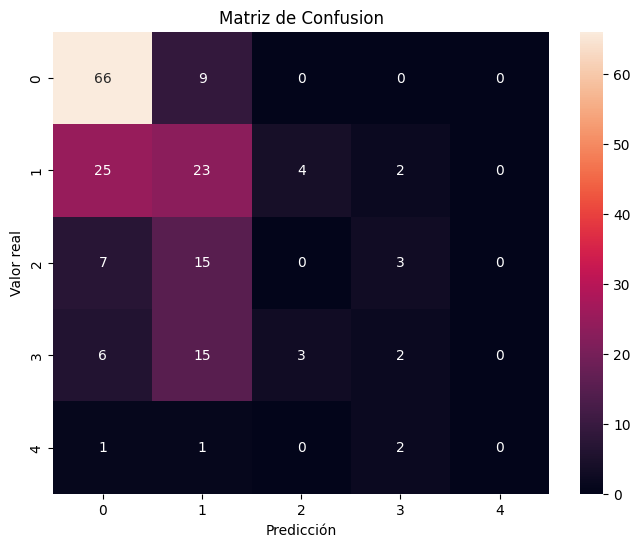

In [ ]:
# Prediccion y metricas de rendimiento
target_pred = model.predict(x_test)

accuracy = accuracy_score(target_test, target_pred)
print(f"Exactitud del modelo: {accuracy:.2%}")

cnf_mtrx = confusion_matrix(target_test, target_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cnf_mtrx, annot=True)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusion")
plt.show()

De acuerdo con la resultados obtenidos podemos concluir lo siguiente:

La exactitud del modelo obtuvo un 49%, lo que nos diria que la mitad de las predicciones que realiza son correctas.

Ahora, en cuanto a la matriz de confucion, se puede apreciar que predijo de manera correcta 66 y 9 confundio con caso 1, ahora los casos positivos el modelo tiende a confundirse bastante entre casos positivos; para casos 1 los confunde bastante con 0 y para casos mas altos se tiende a confundir aun mas.
Se podria decir que predice bastante bien los casos negativos, mas para casos positivos se confunde bastante entre casos, mas se podria decir que predice de manera aceptable si un paciente es positivo o no sin contar la gravedad, aunque si se confunde bastante con casos 1

In [ ]:
target_test.value_counts()

,count
num,
0,75
1,54
3,26
2,25
4,4


In [ ]:
target_pred = pd.Series(target_pred)
target_pred.value_counts()

,count
0,105
1,63
3,9
2,7
